In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
import scipy.cluster.hierarchy as shc
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from tqdm import tqdm

%matplotlib inline

# define data

### scaled data

In [19]:
df_scaled = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_scaled.csv')

In [20]:
df_scaled['Paced_music_mean_CV_iti'] = np.mean(df_scaled[['Paced_music_badine_mean_CV_iti', 'Paced_music_ross_mean_CV_iti']])

In [21]:
fiveash_columns = [
    'BAT_all_dprime',
    'Anisochrony_tones_threshold',
    'Unpaced_spontaneous_right_CV_iti',
    'SyncCont_metro_600_mean_CV_iti',
    'Paced_metro_600_mean_CV_iti',
]
#     'Paced_music_mean_CV_iti',


df_scaled_fivash = df_scaled[fiveash_columns]

### tSNE data

<AxesSubplot: >

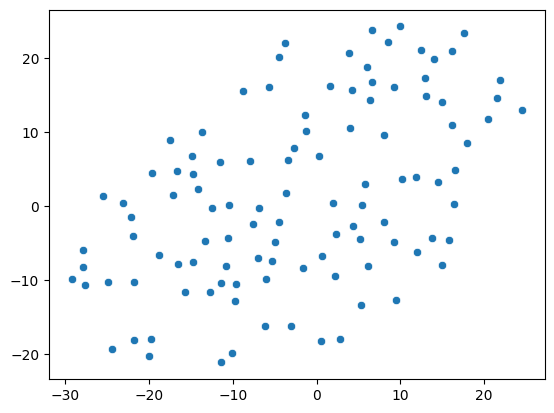

In [5]:
tsne_norm = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=10)
tsne_scaled_data = tsne_norm.fit_transform(df_scaled.iloc[:,2:])
sns.scatterplot(x=tsne_scaled_data[:,0], y=tsne_scaled_data[:,1])

### PCA data

<AxesSubplot: >

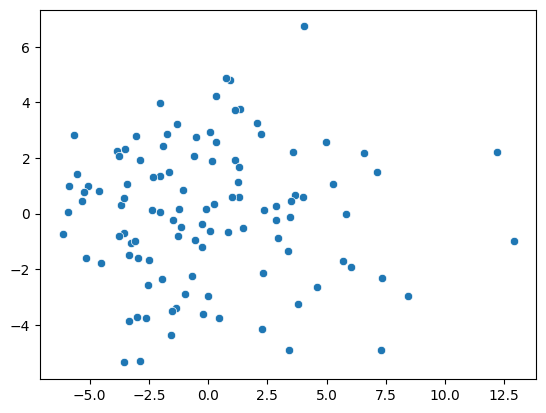

In [6]:
pca_norm = PCA(n_components=2)
pca_norm.fit(df_scaled.iloc[:,2:])
pca_scaled_data = pca_norm.transform(X=df_scaled.iloc[:,2:])
sns.scatterplot(x=pca_scaled_data[:,0], y=pca_scaled_data[:,1])

### define X

In [22]:
# X = tsne_scaled_data
# X = pca_scaled_data
X = df_scaled.iloc[:,2:]
# X = synthetic_X

# BIC method

## define score 

In [8]:
def gmm_bic_score(estimator, X):
    return -estimator.bic(X)

## define grid search

In [12]:
param_grid = {
    "n_components": range(1, 7),
    "covariance_type": ["spherical", "tied", "diag"],
}
grid_search = GridSearchCV(
    GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
)

## fit grid search

In [13]:
grid_search.fit(X)

GridSearchCV(estimator=GaussianMixture(),
             param_grid={'covariance_type': ['spherical', 'tied', 'diag'],
                         'n_components': range(1, 7)},
             scoring=<function gmm_bic_score at 0x7f9d62d1e4d0>)

## show dataframe of results

In [14]:
df = pd.DataFrame(grid_search.cv_results_)[
    ["param_n_components", "param_covariance_type", "mean_test_score"]
]
df["mean_test_score"] = -df["mean_test_score"]
df = df.rename(
    columns={
        "param_n_components": "Number of components",
        "param_covariance_type": "Type of covariance",
        "mean_test_score": "BIC score",
    }
)
df.sort_values(by="BIC score").head()

,Number of components,Type of covariance,BIC score
12,1,diag,3872.451088
0,1,spherical,3897.459132
1,2,spherical,3938.669172
13,2,diag,3945.393398
2,3,spherical,4013.466198


## plot the results

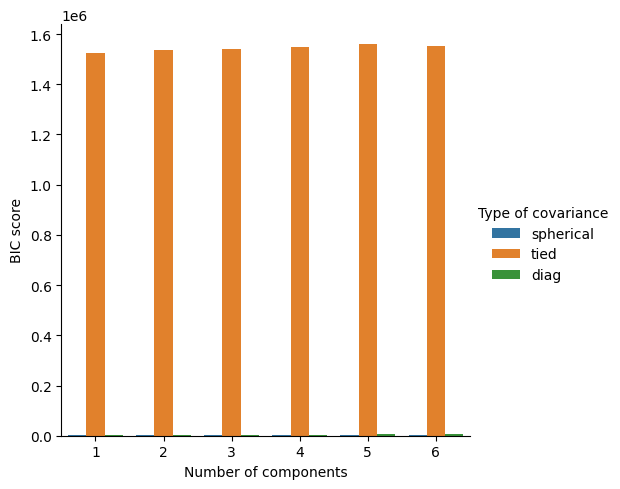

In [15]:
sns.catplot(
    data=df,
    kind="bar",
    x="Number of components",
    y="BIC score",
    hue="Type of covariance",
)
plt.show()

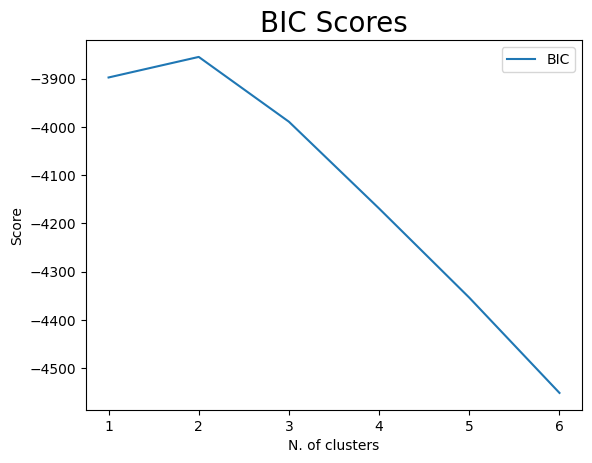

In [18]:
bics_err = -df[df['Type of covariance'] == 'spherical']['BIC score']
n_clusters = np.arange(1,7)
plt.plot(n_clusters,bics_err, label='BIC')
plt.title("BIC Scores", fontsize=20)
plt.xticks(n_clusters)
plt.xlabel("N. of clusters")
plt.ylabel("Score")
plt.legend()

# Silohuette coefficient

## define score 

In [19]:
def gmm_silohuette_score(estimator, X):
    labels=estimator.predict(X)
#     print('here labels:', len(labels), '\n', labels)
    sil=metrics.silhouette_score(X, labels, metric='euclidean')
    return sil

## define grid search

In [20]:
param_grid = {
    "n_components": range(2, 7),
    "covariance_type": ["spherical", "tied", "diag", "full"],
}
grid_search = GridSearchCV(
    GaussianMixture(), param_grid=param_grid, scoring=gmm_silohuette_score
)

## fit grid search

In [21]:
grid_search.fit(X)

/home/matin/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:824: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/matin/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 811, in _score
    scores = scorer(estimator, X_test)
  File "/tmp/ipykernel_2607185/3150506003.py", line 4, in gmm_silohuette_score
    sil=metrics.silhouette_score(X, labels, metric='euclidean')
  File "/home/matin/.local/lib/python3.10/site-packages/sklearn/utils/_param_validation.py", line 211, in wrapper
    return func(*args, **kwargs)
  File "/home/matin/.local/lib/python3.10/site-packages/sklearn/metrics/cluster/_unsupervised.py", line 131, in silhouette_score
    return np.mean(silhouette_samples(X, labels, metric=metric, **kwds))
  File "/home/matin/.local/lib/python3.10/site-packages/sklearn/utils/_param_validation.py", line 184, in 

GridSearchCV(estimator=GaussianMixture(),
             param_grid={'covariance_type': ['spherical', 'tied', 'diag',
                                             'full'],
                         'n_components': range(2, 7)},
             scoring=<function gmm_silohuette_score at 0x7f364c21cb80>)

## show dataframe of results

In [166]:
df = pd.DataFrame(grid_search.cv_results_)[
    ["param_n_components", "param_covariance_type", "mean_test_score"]
]
df = df.rename(
    columns={
        "param_n_components": "Number of components",
        "param_covariance_type": "Type of covariance",
        "mean_test_score": "Silohuette score",
    }
)
df.sort_values(by="Silohuette score").tail()

,Number of components,Type of covariance,Silohuette score
1,3,spherical,0.198281
15,2,full,0.315513
10,2,diag,0.335274
5,2,tied,0.399348
0,2,spherical,0.424408


## plot the results

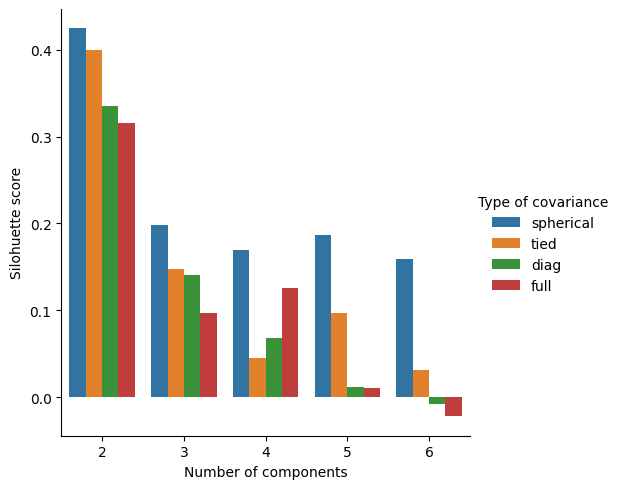

In [167]:
sns.catplot(
    data=df,
    kind="bar",
    x="Number of components",
    y="Silohuette score",
    hue="Type of covariance",
)
plt.show()

# PCA results BIC Original

In [47]:
X = df_scaled.iloc[:,2:]
scores3 = []
for i in tqdm(range(20)):
    gmm=GaussianMixture(n_components=4, covariance_type='full', n_init=i+1000).fit(X)
    test_score = gmm.bic(X)
    scores3.append(test_score)

scores3

100%|███████████████████████████████████████████████████████████████████████████████████| 20/20 [01:17<00:00,  3.88s/it]


[-616.9874224038867,
 -635.8044621565277,
 -615.7801745888137,
 -711.3969250721784,
 -640.9185524639252,
 -579.8938629124314,
 -609.8935574024727,
 -683.8985805287302,
 -646.501159967338,
 -635.9462825272858,
 -571.7775850672842,
 -707.7455085905749,
 -583.8281504367405,
 -658.0986444816372,
 -661.1114970814742,
 -681.2322577307059,
 -724.6217477478785,
 -781.4031052901628,
 -689.5371296646917,
 -649.682789010847]

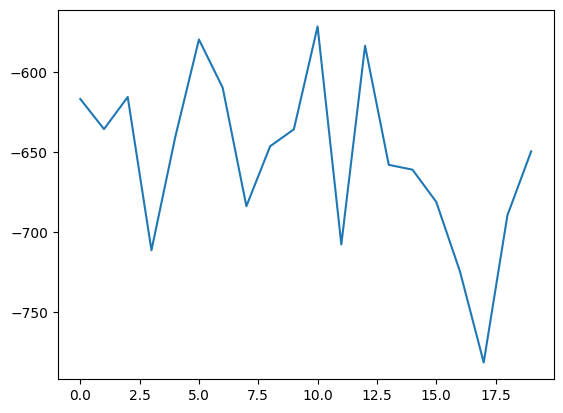

In [48]:
plt.plot(scores3)

In [ ]:
np.std(scores[10:])

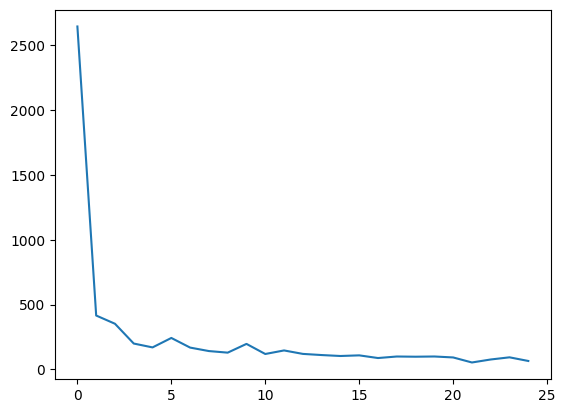

In [57]:
stds = []
for i in range(25):
    stds.append(np.std(scores[i*20:(i+1)*20 -1]))
    
plt.plot(stds)

In [52]:
np.std(scores)

708.2561423262082

In [45]:
X = df_scaled.iloc[:,2:]
pca = PCA(n_components=2)
pca.fit(X)
x_pca = pca.transform(X)

scores2 = []
for i in tqdm(range(500)):
    gmm=GaussianMixture(n_components=4, covariance_type='full', n_init=i+1).fit(x_pca)
    test_score = gmm.bic(x_pca)
    scores2.append(test_score)


scores2

100%|█████████████████████████████████████████████████████████████████████████████████| 500/500 [14:02<00:00,  1.69s/it]


[1171.4470788683104,
 1172.015755155328,
 1166.1339631443182,
 1170.342560211186,
 1167.1954373488343,
 1169.4480921590657,
 1168.1493337252716,
 1166.1339631443182,
 1166.2364906207592,
 1169.6758035580117,
 1166.1960171197038,
 1166.2375856971112,
 1144.2608106208295,
 1169.5688660884878,
 1144.307327870068,
 1166.2407286430396,
 1166.070032705037,
 1166.3327313679927,
 1166.6342643271098,
 1144.1570931295576,
 1166.1339631443182,
 1166.0266670480687,
 1144.0326321609668,
 1165.8844171502137,
 1166.1960171197038,
 1144.1431069575888,
 1166.1154225926848,
 1144.2888884909876,
 1143.9578123550812,
 1144.2608106208295,
 1144.0986641703835,
 1137.614713794841,
 1144.307327870068,
 1140.3714558079373,
 1144.307327870068,
 1166.1960171197038,
 1144.0326321609668,
 1139.9261347684383,
 1144.2399811706782,
 1144.1431069575888,
 1166.2407286430396,
 1166.1339631443182,
 1144.0326321609668,
 1144.0719158282461,
 1166.1339631443182,
 1144.0719158282461,
 1144.0719158282461,
 1137.5991617284135,

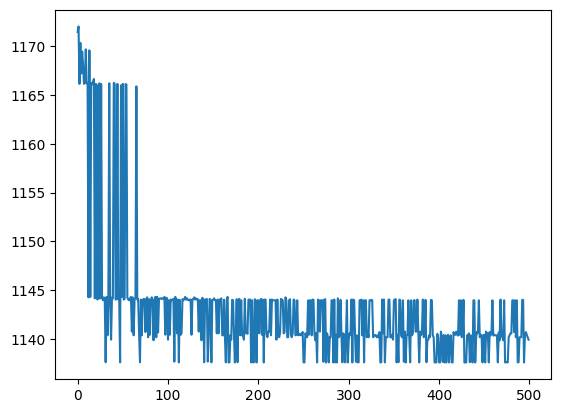

In [46]:
plt.plot(scores2)

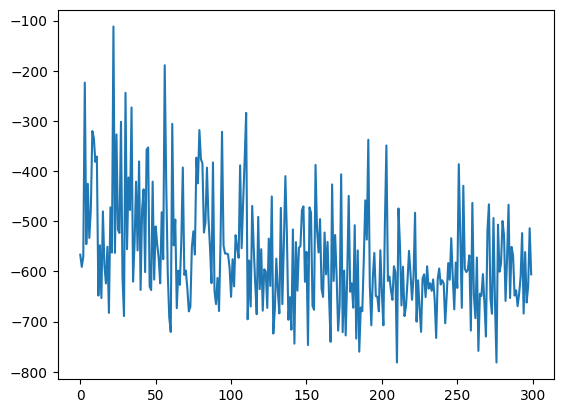

In [44]:
plt.plot(scores[200:])

In [37]:
pca_n_components = range(2, 60)
gmm_n_components = range(1, 7)
gmm_covariance = ["spherical", "tied", "diag", "full"]
results = {'pca_n_components':[], 'gmm_n_components':[], 'gmm_covariance':[], 'test_score':[]}
X = df_scaled.iloc[:,2:]
for pca_n in tqdm(pca_n_components):
    for gmm_n in gmm_n_components:
        for c_type in gmm_covariance:
            pca = PCA(n_components=pca_n)
            pca.fit(X)
            x_pca = pca.transform(X)
            gmm=GaussianMixture(n_components=gmm_n, covariance_type=c_type, n_init=200).fit(x_pca) 
            test_score = gmm.bic(x_pca)
            results['pca_n_components'].append(pca_n)
            results['gmm_n_components'].append(gmm_n)
            results['gmm_covariance'].append(c_type)
            results['test_score'].append(test_score)

            
df_result = pd.DataFrame(results)[["pca_n_components", "gmm_n_components", "gmm_covariance", "test_score"]]            

100%|███████████████████████████████████████████████████████████████████████████████████| 58/58 [24:15<00:00, 25.09s/it]


In [38]:
with pd.option_context('display.max_rows', None,):
    print(df_result.sort_values(by='test_score'))

      pca_n_components  gmm_n_components gmm_covariance    test_score
1383                59                 4           full   -507.216520
1359                58                 4           full   -299.273632
1219                52                 5           full     -1.346100
1267                54                 5           full     68.644637
1311                56                 4           full     85.912158
1339                57                 5           full    134.589268
1195                51                 5           full    156.778741
1171                50                 5           full    179.067491
1243                53                 5           full    193.202215
1335                57                 4           full    219.848533
1315                56                 5           full    390.490185
1287                55                 4           full    411.123043
1123                48                 5           full    460.064928
1387                

In [33]:
gmm_two_works = []

for pca_n in pca_n_components:
    for c_type in gmm_covariance:
        temp_df = df_result[(df_result['gmm_covariance']==c_type) & (df_result['pca_n_components']==pca_n)]
        if temp_df.sort_values(by='test_score')['gmm_n_components'].values[0] == 1:
            value = temp_df[temp_df['gmm_n_components']==1]['test_score']
            gmm_two_works.append(f'pca_components: {str(pca_n)} | type: {str(c_type)} | value:{value.values[0]}' )

gmm_two_works

['pca_components: 2 | type: tied | value:1117.3410221610734',
 'pca_components: 2 | type: diag | value:1112.6588909339491',
 'pca_components: 2 | type: full | value:1117.3410221610734',
 'pca_components: 3 | type: tied | value:1602.3860392849929',
 'pca_components: 3 | type: diag | value:1588.3396456036203',
 'pca_components: 3 | type: full | value:1602.3860392849926',
 'pca_components: 7 | type: tied | value:3356.635453321077',
 'pca_components: 7 | type: full | value:3356.6354533210774',
 'pca_components: 8 | type: tied | value:3764.6221890741886',
 'pca_components: 8 | type: full | value:3764.6221890741886',
 'pca_components: 9 | type: tied | value:4168.590771408089',
 'pca_components: 9 | type: full | value:4168.590771408088',
 'pca_components: 10 | type: tied | value:4575.673918406044',
 'pca_components: 11 | type: tied | value:4979.868361975707',
 'pca_components: 11 | type: full | value:4979.868361975707',
 'pca_components: 12 | type: tied | value:5380.527196896223',
 'pca_compo

In [40]:
df_result[(df_result['gmm_covariance']=='full') & (df_result['pca_n_components']==53)].sort_values(by='test_score')

,pca_n_components,gmm_n_components,gmm_covariance,test_score
1239,53,4,full,2026.630714
1243,53,5,full,6281.921425
1247,53,6,full,8866.947634
1231,53,2,full,15138.079845
1235,53,3,full,17581.702175
1227,53,1,full,18030.148285


# PCA results BIC Fivash

In [62]:
df_scaled_fivash.shape

(108, 5)

In [64]:
pca_n_components = range(2, 4)
gmm_n_components = range(1, 7)
gmm_covariance = ["spherical", "tied", "diag", "full"]
results = {'pca_n_components':[], 'gmm_n_components':[], 'gmm_covariance':[], 'test_score':[]}
X = df_scaled_fivash.iloc[:,2:]
for pca_n in pca_n_components:
    for gmm_n in gmm_n_components:
        for c_type in gmm_covariance:
            pca = PCA(n_components=pca_n)
            pca.fit(X)
            x_pca = pca.transform(X)
            gmm=GaussianMixture(n_components=gmm_n, covariance_type=c_type).fit(x_pca) 
            test_score = gmm.bic(x_pca)
            results['pca_n_components'].append(pca_n)
            results['gmm_n_components'].append(gmm_n)
            results['gmm_covariance'].append(c_type)
            results['test_score'].append(test_score)

            
df_result = pd.DataFrame(results)[["pca_n_components", "gmm_n_components", "gmm_covariance", "test_score"]]            

In [73]:
df_result

,pca_n_components,gmm_n_components,gmm_covariance,test_score
0,2,1,spherical,-2573.073104
1,2,1,tied,-2563.708844
2,2,1,diag,-2568.390975
3,2,1,full,-2563.708844
4,2,2,spherical,-2554.344579
5,2,2,tied,-2549.662450
6,2,2,diag,-2544.980319
7,2,2,full,-2535.616056
8,2,3,spherical,-2535.616054
9,2,3,tied,-2535.616056


In [72]:
gmm_two_works = []

for pca_n in pca_n_components:
    for c_type in gmm_covariance:
        temp_df = df_result[(df_result['gmm_covariance']==c_type) & (df_result['pca_n_components']==pca_n)]
        if temp_df.sort_values(by='test_score')['gmm_n_components'].values[0] == 1:
            value = temp_df[temp_df['gmm_n_components']==1]['test_score']
            gmm_two_works.append(f'{str(pca_n)} with {str(c_type)} works with value {value.values[0]}' )

gmm_two_works

['2 with spherical works with value -2573.0731042863767',
 '2 with tied works with value -2563.7088435379255',
 '2 with diag works with value -2568.3909747650496',
 '2 with full works with value -2563.7088435379255',
 '3 with spherical works with value -3861.9728474151607',
 '3 with tied works with value -3838.562194118636',
 '3 with diag works with value -3852.6085878000085',
 '3 with full works with value -3838.562194118636']

In [50]:
df_result[(df_result['gmm_covariance']=='spherical') & (df_result['pca_n_components']==59)].sort_values(by='test_score')

,pca_n_components,gmm_n_components,gmm_covariance,test_score
1388,59,6,spherical,-34279.819287
1384,59,5,spherical,-34172.458371
1380,59,4,spherical,-33832.276453
1376,59,3,spherical,-32981.447373
1372,59,2,spherical,-32087.205831
1368,59,1,spherical,-28632.842451
